# 02 — Exploratory Data Analysis

Runs on `data/processed/combined_cleaned.parquet` (produced by `01_validate_data` → `02_preprocess` → `03_combine_data`).

Covers guide §12: class distribution, missing values, data types, summary statistics, correlation, and low-variance features. Figures are written to `figures/`, tables to `results/metrics/`.

The full dataset is ~15.7M rows, so the expensive steps (`describe`, correlation) run on a fixed random **sample**; cheap column reductions run on the full frame.

## Findings summary

Cleaned dataset: **15,727,888 network flows · 78 numeric features · 15 traffic classes**, combined from 10 CSE-CIC-IDS2018 capture days.

- **Severe class imbalance.** 85.0% Benign (13.37M) vs. 15.0% attack (2.35M). Individual attacks range from 668k (DDoS-HOIC) down to **87 SQL-Injection** and **230 Brute-Force-XSS** samples → the core modelling challenge, and why the pipeline starts with **binary** (benign vs. attack) before multiclass.
- **Clean data.** Zero missing and zero infinite values after cleaning (duplicates, NaN/inf, and embedded repeated-header rows removed per file).
- **8 constant (zero-variance) features** carry no signal (`Fwd/Bwd Byts/b Avg`, `Fwd/Bwd Blk Rate Avg`, `Fwd/Bwd Pkts/b Avg`, `Bwd PSH Flags`, `Bwd URG Flags`) — first candidates for removal in feature selection.
- **Heavy feature redundancy.** Many forward/backward flow statistics are **perfectly correlated** (e.g. `Subflow Fwd Pkts` ↔ `Tot Fwd Pkts`, `Bwd Pkt Len Mean` ↔ `Bwd Seg Size Avg`) — to be pruned later via RFE / SHAP.
- **Feature scales vary by orders of magnitude** (byte counts vs. ratios vs. flags) — motivates scaling for linear models; tree models (XGBoost / Random Forest) are scale-invariant.

*Reproduce: run `src/01_validate_data.py → 02_preprocess.py → 03_combine_data.py`, then **Kernel → Restart Kernel and Run All Cells** here.*

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve the project root whether this runs from notebooks/ or the repo root.
_TARGET = "data/processed/combined_cleaned.parquet"
ROOT = Path.cwd()
while not (ROOT / _TARGET).exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / _TARGET).exists():
    raise FileNotFoundError(
        f"Could not locate {_TARGET} above {Path.cwd()}. "
        "Run this notebook from within the project (e.g. the notebooks/ folder), "
        "and make sure the cleaning pipeline (01->02->03) has been run."
    )

DATA_FILE = ROOT / _TARGET
FIG_DIR = ROOT / "figures"
METRICS_DIR = ROOT / "results/metrics"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DESC_SAMPLE = 200_000   # rows for describe()
CORR_SAMPLE = 50_000    # rows for correlation

df = pd.read_parquet(DATA_FILE)
# Numeric feature columns, computed from dtypes (no big data copy).
numeric_cols = [c for c, dt in df.dtypes.items() if pd.api.types.is_numeric_dtype(dt)]
print("shape:", df.shape)
print("numeric feature columns:", len(numeric_cols))
df.head()

shape: (15727888, 80)
numeric feature columns: 78


,ACK Flag Cnt,Active Max,Active Mean,Active Min,Active Std,Bwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Header Len,Bwd IAT Max,Bwd IAT Mean,...,SourceFile,Subflow Bwd Byts,Subflow Bwd Pkts,Subflow Fwd Byts,Subflow Fwd Pkts,Tot Bwd Pkts,Tot Fwd Pkts,TotLen Bwd Pkts,TotLen Fwd Pkts,URG Flag Cnt
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,31525.0,8569.50000,...,Friday-02-03-2018_TrafficForML_CICFlowMeter_cl...,3773.0,7.0,553.0,9.0,7.0,9.0,3773.0,553.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.00000,...,Friday-02-03-2018_TrafficForML_CICFlowMeter_cl...,0.0,1.0,38.0,2.0,1.0,2.0,0.0,38.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,312.0,133669.0,18494.57143,...,Friday-02-03-2018_TrafficForML_CICFlowMeter_cl...,10527.0,15.0,1086.0,11.0,15.0,11.0,10527.0,1086.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,...,Friday-02-03-2018_TrafficForML_CICFlowMeter_cl...,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,272.0,135611.0,21082.83333,...,Friday-02-03-2018_TrafficForML_CICFlowMeter_cl...,6141.0,13.0,1285.0,9.0,13.0,9.0,6141.0,1285.0,0.0


## 12.1 Class distribution

In [2]:
label_counts = df["Label"].value_counts()
label_counts.to_frame("count").to_csv(METRICS_DIR / "class_distribution.csv")
print("classes:", df["Label"].nunique())
label_counts

classes: 15


Label
Benign                      13374921
DDOS attack-HOIC              668461
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              434873
Bot                           282310
Infilteration                 160604
SSH-Bruteforce                117322
DoS attacks-GoldenEye          41455
FTP-BruteForce                 39346
DoS attacks-SlowHTTPTest       19462
DoS attacks-Slowloris          10285
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

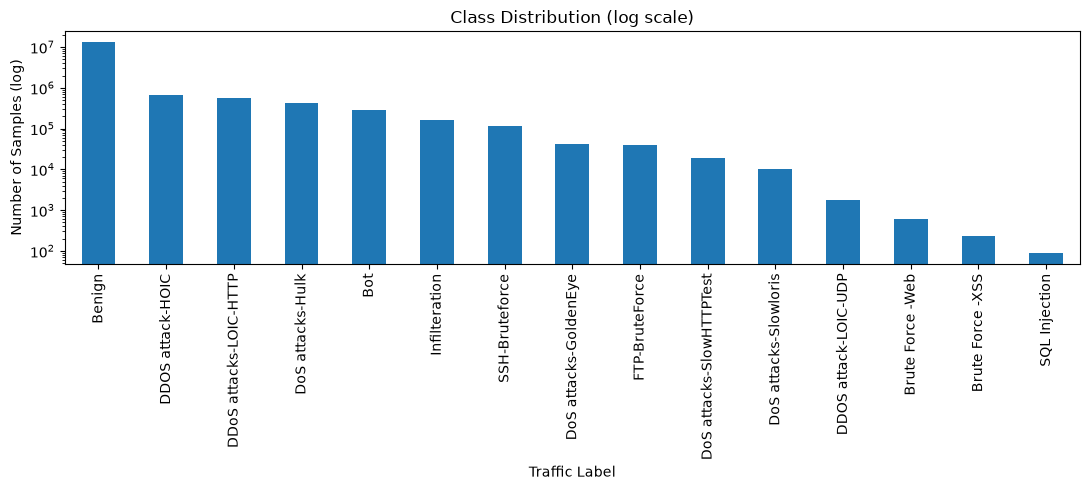

In [3]:
# Log scale: the classes span ~13M (Benign) down to <100 (SQL Injection).
ax = label_counts.plot(kind="bar", figsize=(11, 5), logy=True)
ax.set_title("Class Distribution (log scale)")
ax.set_xlabel("Traffic Label")
ax.set_ylabel("Number of Samples (log)")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Binary view (Benign vs any attack) — the first modelling target per guide §13.
binary = df["Label"].astype(str).str.strip().str.lower().ne("benign").astype(int)
print(binary.value_counts().rename({0: "Benign", 1: "Attack"}).to_string())
print(f"\nattack fraction: {binary.mean():.4f}")

Label
Benign    13374921
Attack     2352967

attack fraction: 0.1496


## 12.2 Missing values

Should be zero — the cleaning pipeline dropped all NaN/inf rows. Confirming it here is a stated cleaning outcome for the Results chapter.

In [5]:
na = df.isna().sum()
print("total missing cells:", int(na.sum()))
na[na > 0].sort_values(ascending=False).head(20)

total missing cells: 0


Series([], dtype: int64)

## 12.3 Data types

In [6]:
df.dtypes.value_counts()

float64    78
str         2
Name: count, dtype: int64

## 12.4 Summary statistics (sampled)

In [7]:
desc_sample = df.sample(n=min(DESC_SAMPLE, len(df)), random_state=RANDOM_STATE)[numeric_cols]
desc = desc_sample.describe().T
desc.to_csv(METRICS_DIR / "summary_statistics.csv")
desc

,count,mean,std,min,25%,50%,75%,max
ACK Flag Cnt,200000.0,0.328580,4.696981e-01,0.0,0.0,0.0,1.00,1.000000e+00
Active Max,200000.0,274989.950275,3.412567e+06,0.0,0.0,0.0,0.00,1.110817e+08
Active Mean,200000.0,179884.911743,2.551170e+06,0.0,0.0,0.0,0.00,1.110817e+08
Active Min,200000.0,117914.815900,2.125948e+06,0.0,0.0,0.0,0.00,1.110817e+08
Active Std,200000.0,93099.436307,1.594110e+06,0.0,0.0,0.0,0.00,6.376724e+07
...,...,...,...,...,...,...,...,...
Tot Bwd Pkts,200000.0,6.415680,1.431515e+02,0.0,0.0,1.0,4.00,2.237500e+04
Tot Fwd Pkts,200000.0,28.179090,1.744899e+03,1.0,1.0,2.0,5.00,1.784170e+05
TotLen Bwd Pkts,200000.0,4864.414105,2.070054e+05,0.0,0.0,108.0,686.25,3.259659e+07
TotLen Fwd Pkts,200000.0,1113.249620,5.594412e+04,0.0,0.0,44.0,520.00,5.709344e+06


## 12.5 Low-variance features

Computed on the full frame. Zero-variance (constant) features carry no signal and are removal candidates for later feature selection.

In [8]:
# Per-column to avoid copying all numeric columns into one large frame.
variance = pd.Series({c: df[c].var() for c in numeric_cols}).sort_values()
variance.to_frame("variance").to_csv(METRICS_DIR / "feature_variance.csv")
n_zero = int((variance == 0).sum())
print(f"zero-variance (constant) features: {n_zero}")
if n_zero:
    print("constant:", variance[variance == 0].index.tolist())
variance.head(20)

zero-variance (constant) features: 8
constant: ['Fwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Fwd Byts/b Avg', 'Fwd Blk Rate Avg', 'Bwd PSH Flags', 'Bwd URG Flags', 'Bwd Pkts/b Avg']


Fwd Pkts/b Avg       0.000000
Bwd Blk Rate Avg     0.000000
Bwd Byts/b Avg       0.000000
Fwd Byts/b Avg       0.000000
Fwd Blk Rate Avg     0.000000
Bwd PSH Flags        0.000000
Bwd URG Flags        0.000000
Bwd Pkts/b Avg       0.000000
Fwd URG Flags        0.000169
CWE Flag Count       0.000169
FIN Flag Cnt         0.004438
URG Flag Cnt         0.036981
SYN Flag Cnt         0.041140
Fwd PSH Flags        0.041140
RST Flag Cnt         0.156006
ECE Flag Cnt         0.156006
ACK Flag Cnt         0.220459
PSH Flag Cnt         0.237279
Down/Up Ratio        1.017246
Protocol            24.731557
dtype: float64

## 12.6 Correlation (sampled)

A full 79-feature heatmap is unreadable, so we rank the strongest feature pairs and plot only the most-correlated subset.

In [9]:
corr_sample = df.sample(n=min(CORR_SAMPLE, len(df)), random_state=RANDOM_STATE)[numeric_cols]
corr = corr_sample.corr()

# Strongest absolute correlations, upper triangle only.
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.abs().where(mask).stack().sort_values(ascending=False)
print("top 20 most-correlated feature pairs:")
pairs.head(20)

top 20 most-correlated feature pairs:


Bwd Pkt Len Mean   Bwd Seg Size Avg    1.000000
CWE Flag Count     Fwd URG Flags       1.000000
Subflow Fwd Pkts   Tot Fwd Pkts        1.000000
Fwd PSH Flags      SYN Flag Cnt        1.000000
Subflow Fwd Byts   TotLen Fwd Pkts     1.000000
Subflow Bwd Byts   TotLen Bwd Pkts     1.000000
ECE Flag Cnt       RST Flag Cnt        1.000000
Subflow Bwd Pkts   Tot Bwd Pkts        1.000000
Fwd Pkt Len Mean   Fwd Seg Size Avg    1.000000
Bwd Header Len     Tot Bwd Pkts        0.999924
                   Subflow Bwd Pkts    0.999924
Tot Bwd Pkts       TotLen Bwd Pkts     0.999381
Subflow Bwd Pkts   TotLen Bwd Pkts     0.999381
Subflow Bwd Byts   Tot Bwd Pkts        0.999381
                   Subflow Bwd Pkts    0.999381
Bwd Header Len     TotLen Bwd Pkts     0.999226
                   Subflow Bwd Byts    0.999226
Fwd Act Data Pkts  Tot Fwd Pkts        0.999204
                   Subflow Fwd Pkts    0.999204
Fwd Header Len     Tot Fwd Pkts        0.998129
dtype: float64

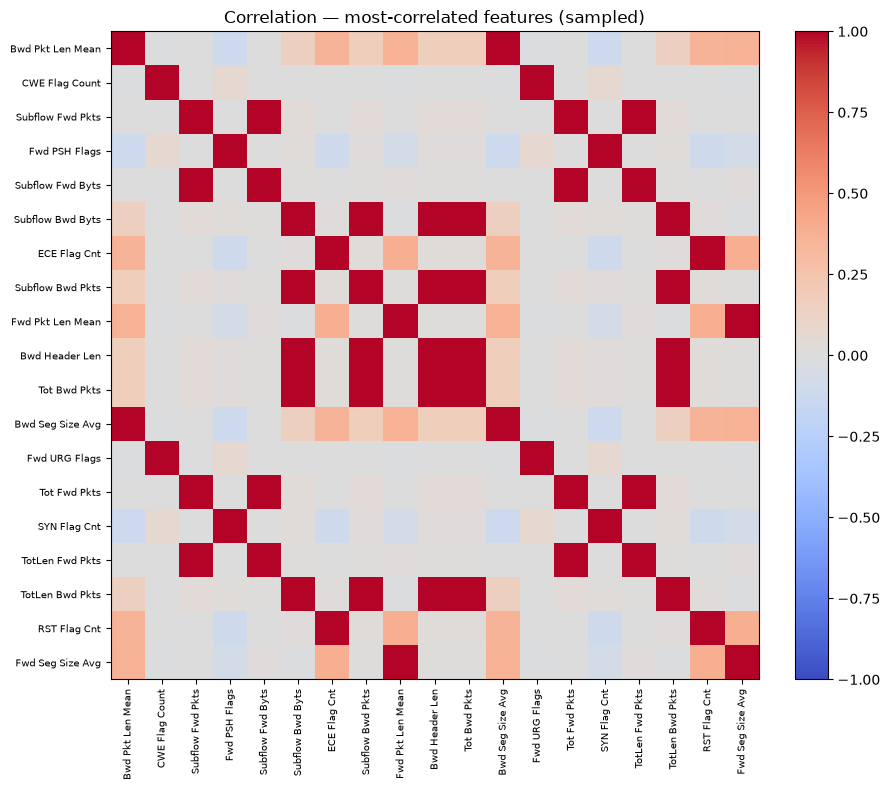

In [10]:
# Heatmap of the features involved in the strongest pairs.
top = pairs.head(15).index
top_feats = pd.Index(list(top.get_level_values(0)) + list(top.get_level_values(1))).unique()
sub = corr.loc[top_feats, top_feats]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats, fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation — most-correlated features (sampled)")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Outputs

**Figures** (`figures/`): `class_distribution.png`, `correlation_heatmap.png`.

**Tables** (`results/metrics/`): `class_distribution.csv`, `summary_statistics.csv`, `feature_variance.csv`.

Duplicate counts and per-file cleaning stats are already in `results/metrics/cleaning_report.json`.

Next: feature preparation and the train/validation/test split (`src/04_prepare_splits.py`, guide §15).